In [12]:
import torch
import torch.nn as nn
import torch.distributions as D
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import clear_output, display
from ale_py.vector_env import AtariVectorEnv
import os

# Build A2C Network
This notebook implements Advantage Actor-Critic (A2C) for Atari Assault.

Implementation summary:
- Use a shared CNN backbone with two heads: Actor (policy) and Critic (state value).
- Collect rollouts from parallel environments to increase sample throughput.
- Compute n-step returns and normalized advantages.
- Optimize policy loss + value loss - entropy bonus, with gradient clipping.
- Save checkpoints and visualize reward/loss trends during training.

In [13]:
class A2CNetwork(nn.Module):
    def __init__(self, action_dim):
        super().__init__()
        self.shared_layer = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(7 * 7 * 64, 512),
            nn.ReLU()
        )
        self.actor_layer = nn.Linear(512, action_dim)
        self.critic_layer = nn.Linear(512, 1)

    def forward(self, x):
        shared_output = self.shared_layer(x)
        action_probs = torch.softmax(self.actor_layer(shared_output), dim=-1)
        state_value = self.critic_layer(shared_output)
        dist = D.Categorical(action_probs)
        return dist, state_value

# Create ALE environment

In [ ]:
class A2CAgent:
    def __init__(self):
        self.envs = AtariVectorEnv(
        'assault',
        num_envs=16,
        frameskip=4,
        stack_num=4,
        num_threads=2
        )

        self.timestep = 0
        self.rewards = []
        self.epochs = []
        self._episode_idx = 0
        self._episode_returns = torch.zeros(self.envs.num_envs, dtype=torch.float32)

        self._plot_window = 50
        self._rolling_queue = deque()
        self._rolling_sum = 0.0
        self._smoothed_rewards = []
        self._smoothed_epochs = []

        self._reward_fig = None
        self._reward_ax = None
        self._reward_raw_line = None
        self._reward_smooth_line = None
        self._max_raw_plot_points = 5000

        self.losses = []
        self.loss_timesteps = []
        self._loss_window = 1000
        self._loss_queue = deque()
        self._loss_sum = 0.0
        self._smoothed_losses = []
        self._smoothed_loss_timesteps = []

    def live_plot_rewards(self):
        if len(self.rewards) == 0:
            return

        if self._reward_fig is None:
            self._reward_fig, self._reward_ax = plt.subplots(figsize=(24, 12))
            (self._reward_raw_line,) = self._reward_ax.plot(
                [], [], label='Reward (raw)', color='tab:blue', alpha=0.2, linewidth=1
            )
            (self._reward_smooth_line,) = self._reward_ax.plot(
                [], [], label=f'Reward (MA-{self._plot_window})', color='tab:orange', linewidth=2
            )
            self._reward_ax.set_xlabel('Episode')
            self._reward_ax.set_ylabel('Reward')
            self._reward_ax.legend()
            self._reward_ax.grid(alpha=0.3)

        raw_x = self.epochs
        raw_y = self.rewards
        if len(raw_x) > self._max_raw_plot_points:
            stride = max(1, len(raw_x) // self._max_raw_plot_points)
            raw_x = raw_x[::stride]
            raw_y = raw_y[::stride]

        self._reward_raw_line.set_data(raw_x, raw_y)
        self._reward_smooth_line.set_data(self._smoothed_epochs, self._smoothed_rewards)

        all_x = list(raw_x) + self._smoothed_epochs
        all_y = list(raw_y) + self._smoothed_rewards
        if len(all_x) > 0 and len(all_y) > 0:
            x_min, x_max = min(all_x), max(all_x)
            y_min, y_max = min(all_y), max(all_y)

            if x_min == x_max:
                x_max = x_min + 1.0
            if y_min == y_max:
                y_max = y_min + 1.0

            y_margin = max(1e-6, 0.05 * (y_max - y_min))
            self._reward_ax.set_xlim(x_min, x_max)
            self._reward_ax.set_ylim(y_min - y_margin, y_max + y_margin)

        self._reward_ax.set_title(f'A2C Episode Reward (window={self._plot_window})')
        clear_output(wait=True)
        display(self._reward_fig)
        
    def live_plot_loss(self):
        if len(self._smoothed_losses) == 0:
            return

        clear_output(wait=True)
        plt.figure(figsize=(20, 12))
        plt.plot(self._smoothed_loss_timesteps, self._smoothed_losses, label='Loss (MA-1000)', color='tab:red')
        plt.xlabel('Timestep')
        plt.ylabel('Loss')
        plt.title(f'A2C Loss vs Timestep (window={self._loss_window})')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    
    def train(self, save_path, net, optimizer, device, gamma=0.99, n_steps=5, total_timestep=1e7):        
        observations, _ = self.envs.reset()
        while self.timestep < total_timestep:
            self.timestep += n_steps * self.envs.num_envs
            
            step_rewards = []
            values = []
            log_probs = []
            masks = []
            entropy = []

            # run n_steps in the environment and collect rewards
            for t in range(n_steps):
                # get action distribution and state value
                observations = torch.tensor(observations, dtype=torch.float32).to(device)
                dist, value = net(observations / 255.0)

                # step
                actions = dist.sample()
                observations, reward, done , _ , _ = self.envs.step(actions.cpu().numpy())
                
                #collect data
                log_probs.append(dist.log_prob(actions))
                step_rewards.append(torch.FloatTensor(reward).to(device))
                values.append(value.squeeze())
                masks.append(torch.FloatTensor(1 - done).to(device))
                entropy.append(dist.entropy())

                # track episode returns for visualization
                reward_cpu = torch.as_tensor(reward, dtype=torch.float32)
                done_cpu = torch.as_tensor(done, dtype=torch.bool)
                self._episode_returns += reward_cpu
                finished_indices = torch.nonzero(done_cpu).squeeze(-1)
                if finished_indices.numel() > 0:
                    for idx in finished_indices.tolist():
                        self._episode_idx += 1
                        self.epochs.append(self._episode_idx)
                        episode_reward = float(self._episode_returns[idx].item())
                        self.rewards.append(episode_reward)

                        if len(self._rolling_queue) == self._plot_window:
                            self._rolling_sum -= self._rolling_queue.popleft()
                        self._rolling_queue.append(episode_reward)
                        self._rolling_sum += episode_reward

                        if len(self._rolling_queue) == self._plot_window:
                            self._smoothed_rewards.append(self._rolling_sum / self._plot_window)
                            self._smoothed_epochs.append(self._episode_idx)

                        self._episode_returns[idx] = 0.0

                        if self._episode_idx % 100 == 0:
                            self.live_plot_rewards()

            # convert list to tensor                
            log_probs = torch.stack(log_probs)
            step_rewards = torch.stack(step_rewards)
            values = torch.stack(values)
            masks = torch.stack(masks)
            entropy = torch.stack(entropy)

            # calculate return
            Return = step_rewards
            with torch.no_grad():
                _, bootstrap_value = net(torch.tensor(observations, dtype=torch.float32).to(device) / 255.0)
                bootstrap_value = bootstrap_value.squeeze()
            for t in reversed(range(n_steps)):
                if t < n_steps - 1:
                    Return[t] += gamma * Return[t + 1] * masks[t]
                else:
                    Return[t] += gamma * bootstrap_value * masks[t]

            # calculate advantage
            Advantage = Return - values
            advantage_mean = Advantage.mean()
            advantage_std = Advantage.std()
            Advantage_norm = (Advantage - advantage_mean) / (advantage_std + 1e-8)
            
            # calculate loss
            loss_policy = -(log_probs * Advantage_norm.detach()).mean()
            loss_value = Advantage.pow(2).mean()
            loss_entropy = entropy.mean()
            loss = loss_policy + 0.5 * loss_value - 0.01 * loss_entropy

            current_loss = float(loss.item())
            self.losses.append(current_loss)
            self.loss_timesteps.append(self.timestep)
            if len(self._loss_queue) == self._loss_window:
                self._loss_sum -= self._loss_queue.popleft()
            self._loss_queue.append(current_loss)
            self._loss_sum += current_loss
            if len(self._loss_queue) == self._loss_window:
                self._smoothed_losses.append(self._loss_sum / self._loss_window)
                self._smoothed_loss_timesteps.append(self.timestep)
            
            # update network
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.5)
            optimizer.step()

            # visualize

            if self.timestep % 1000 == 0:
                print(f'Timestep: {self.timestep}, epoch: {self._episode_idx}, Loss: {loss.item():.4f}, Policy Loss: {loss_policy.item():.4f}, Value Loss: {loss_value.item():.4f}, Entropy: {loss_entropy.item():.4f}',
                      flush=True,
                      end='\r'
                      )

            # save parameters
            if self.timestep % 1000000 == 0:
                path = os.path.join(save_path, f'timesteps_{self.timestep}.pt')
                torch.save(net.state_dict(), path)
            

## Rollout and Optimization Notes
The `A2CAgent` class implements rollout collection and parameter updates.

Key design choices in this implementation:
- Parallel rollout: collect transitions from multiple environments each update.
- Return estimation: bootstrap-based n-step returns.
- Variance reduction: normalize advantages before policy updates.
- Objective: policy loss + value loss - entropy bonus.
- Stability: clip gradient norm before optimizer step.
- Logging: track smoothed rewards and smoothed training loss.

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [16]:
# create network
net = A2CNetwork(action_dim=7).to(device)

In [17]:
# configuring optimizer
lr = 7e-4
alpha = 0.99
epsilon = 1e-5
optimizer = torch.optim.RMSprop(params=net.parameters(), lr=lr, alpha=alpha, eps=epsilon)

In [ ]:
# save_path
from pathlib import Path
save_path = os.path.join('..', 'models', 'a2c')
folder = Path(save_path)
folder.mkdir(exist_ok=True)

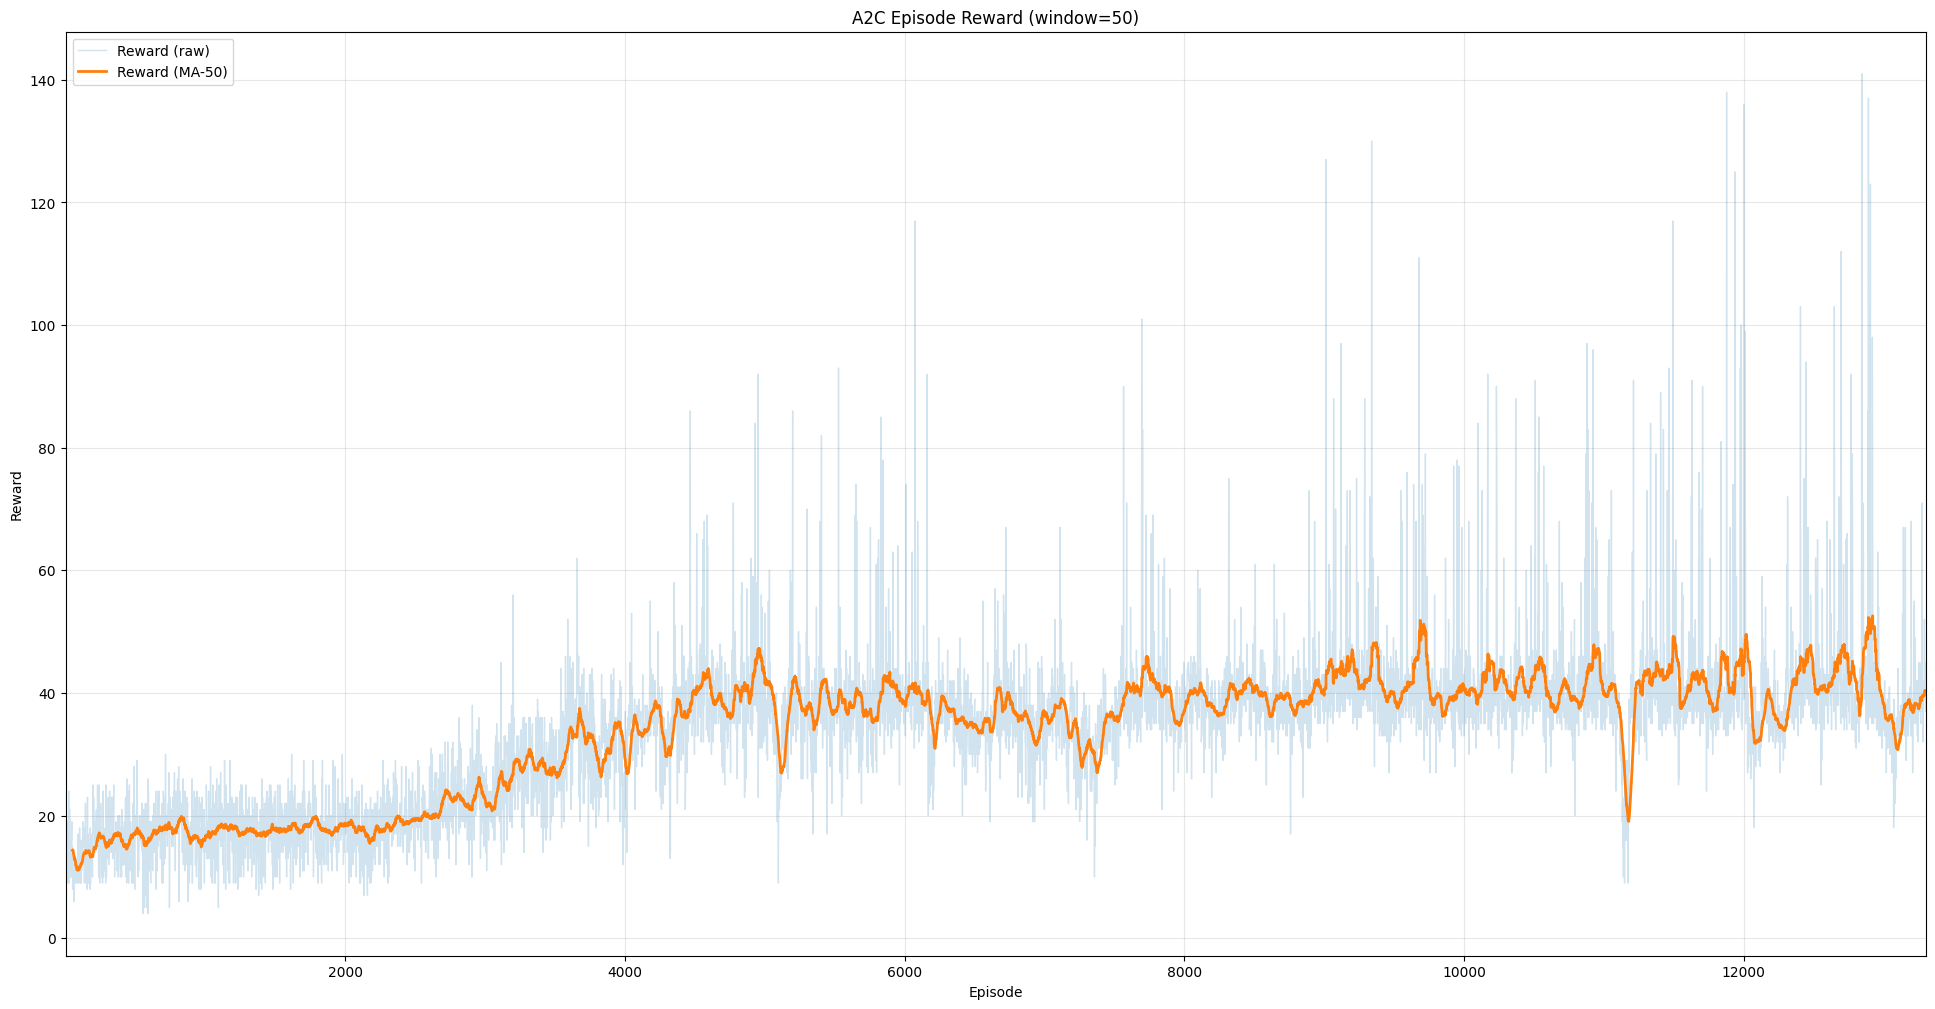

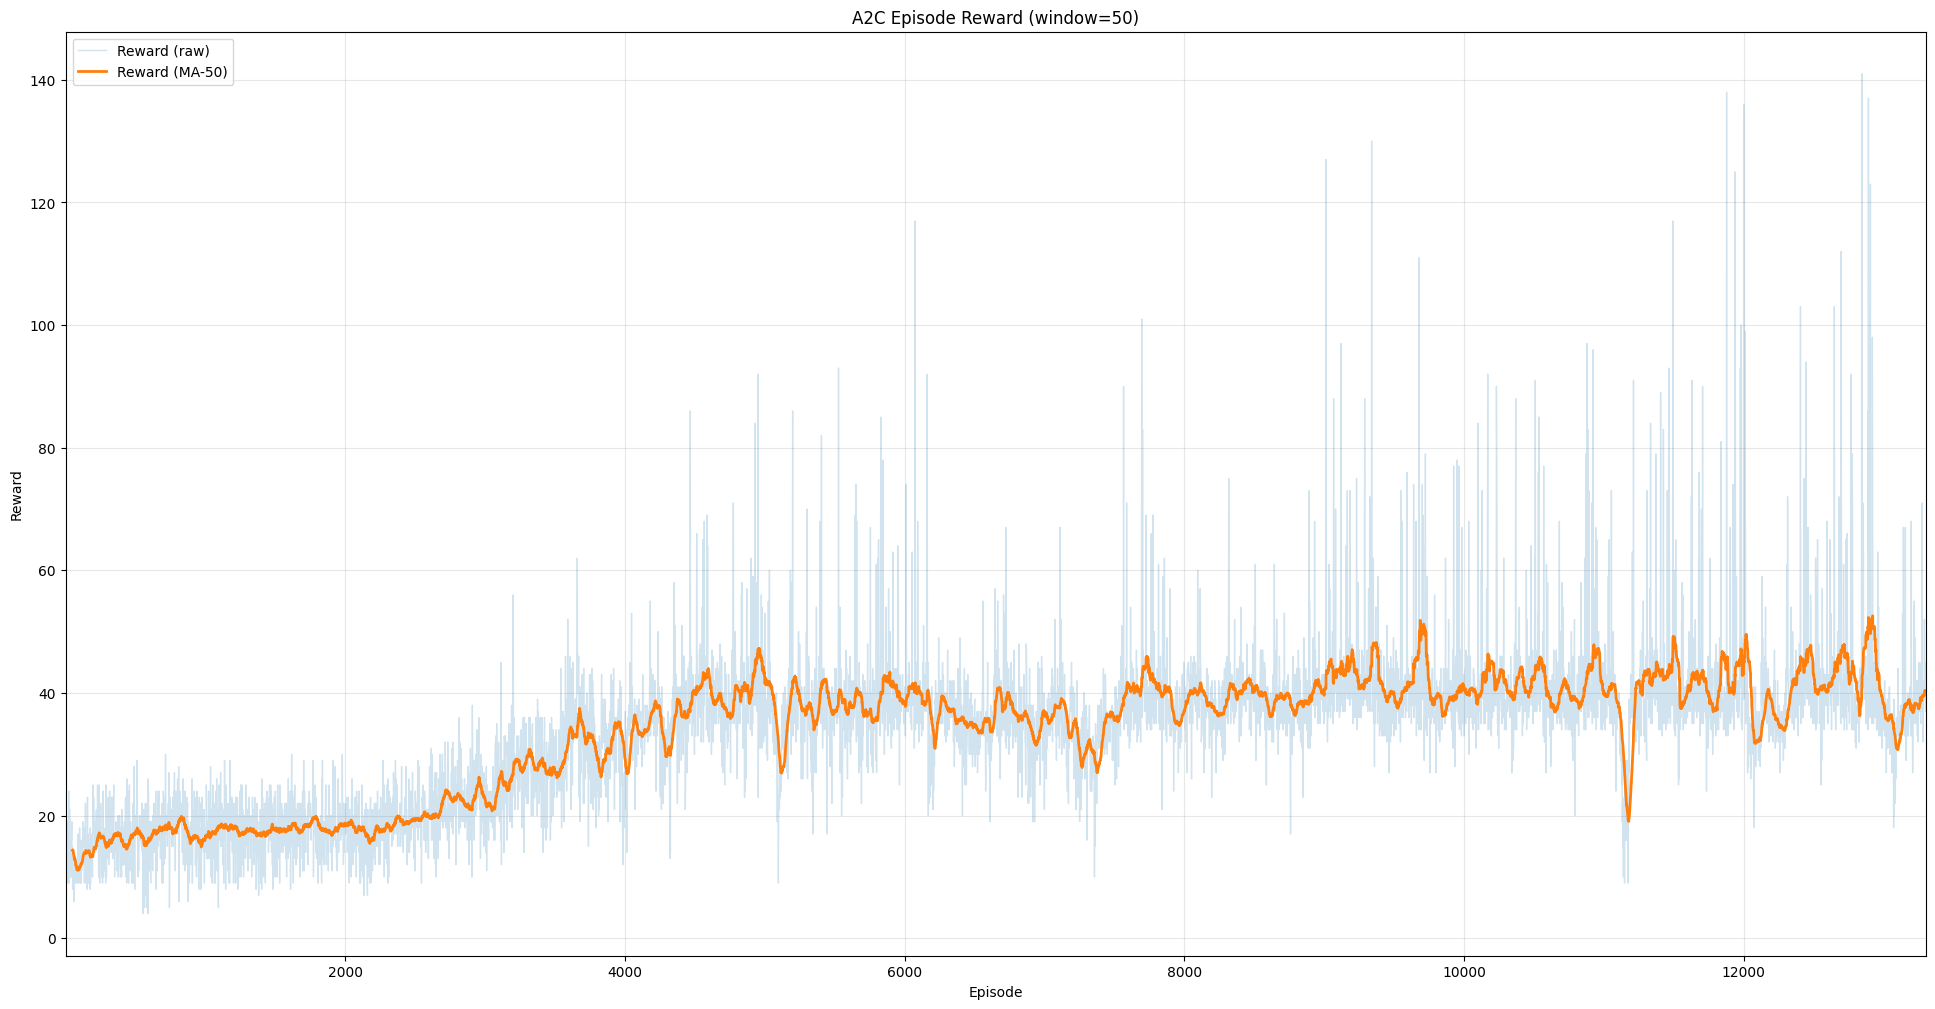

In [20]:
agent = A2CAgent()
agent.train(
            save_path=save_path,
            net=net, 
            optimizer=optimizer, 
            device=device, 
            gamma=0.99, 
            n_steps=5,
            total_timestep=10000000,
            )